Ignorar advertencias, ya que a veces aparecen warning innecesarios

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# Etapa 1: Introducción al Dataset y Análisis de Dimensionalidad
En esta primera etapa, vamos a:

1. Seleccionar un dataset conocido que esté disponible en las librerías como scikit-learn o seaborn.
2. Explorar el dataset, analizando la cantidad de características (dimensionalidad) y la correlación entre las variables.
3. Aplicar un modelo de K-Means inicial sin ninguna técnica de selección de variables, para tener un punto de comparación.

Voy a comenzar con el dataset `Iris` de **`scikit-learn`**, que es muy conocido y tiene una estructura adecuada para clustering y análisis de dimensionalidad.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


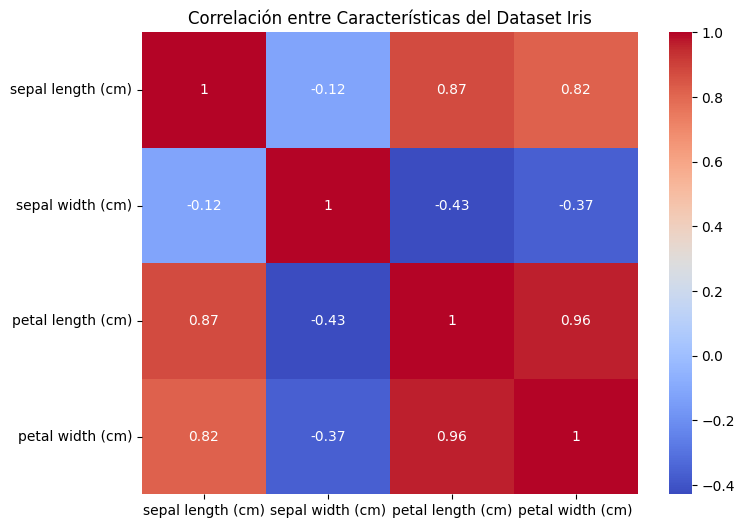

In [ ]:
# Cargar el dataset Iris de scikit-learn
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Explorar la dimensionalidad del dataset
X.info()

# Crear un gráfico de correlación para ver las relaciones entre las características
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre Características del Dataset Iris')
plt.show()


Hemos cargado el dataset Iris, que tiene 150 observaciones y 4 características:

* Sepal length (cm)
* Sepal width (cm)
* Petal length (cm)
* Petal width (cm)

En la visualización de la matriz de correlación, podemos observar que algunas características están bastante correlacionadas, como `petal length` y `petal width`. Esto nos da una pista sobre la posible redundancia de algunas variables.

# Etapa 2: Modelo Inicial de K-Means (sin selección de variables)
En esta etapa vamos a:

1. Aplicar un modelo de K-Means inicial sobre el dataset Iris sin realizar ningún tipo de selección de variables.
2. Visualizar los resultados y obtener una línea base para comparar con los futuros modelos donde sí aplicaremos selección de variables.

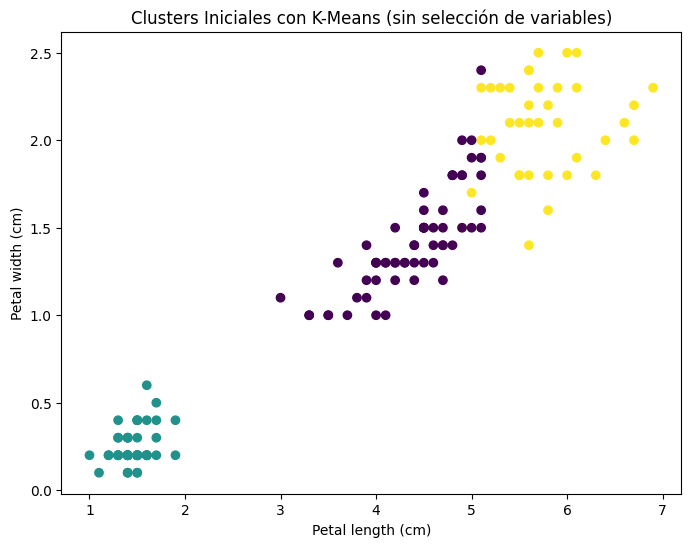

In [ ]:
from sklearn.cluster import KMeans
# Aplicar K-Means al dataset Iris sin selección de variables ni PCA
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Graficar los clusters usando dos características originales (Petal length y Petal width)
plt.figure(figsize=(8, 6))
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=kmeans.labels_, cmap='viridis')
plt.title('Clusters Iniciales con K-Means (sin selección de variables)')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.show()


Para comparar los clusters generados por K-Means con las clases originales del dataset Iris, vamos a hacer lo siguiente:

1. Asignar los clusters predichos por K-Means a los puntos de datos.
2. Comparar los clusters de K-Means con las clases originales del dataset Iris.
3. Visualizar la comparación para ver cómo de bien los clusters coinciden con las clases originales.

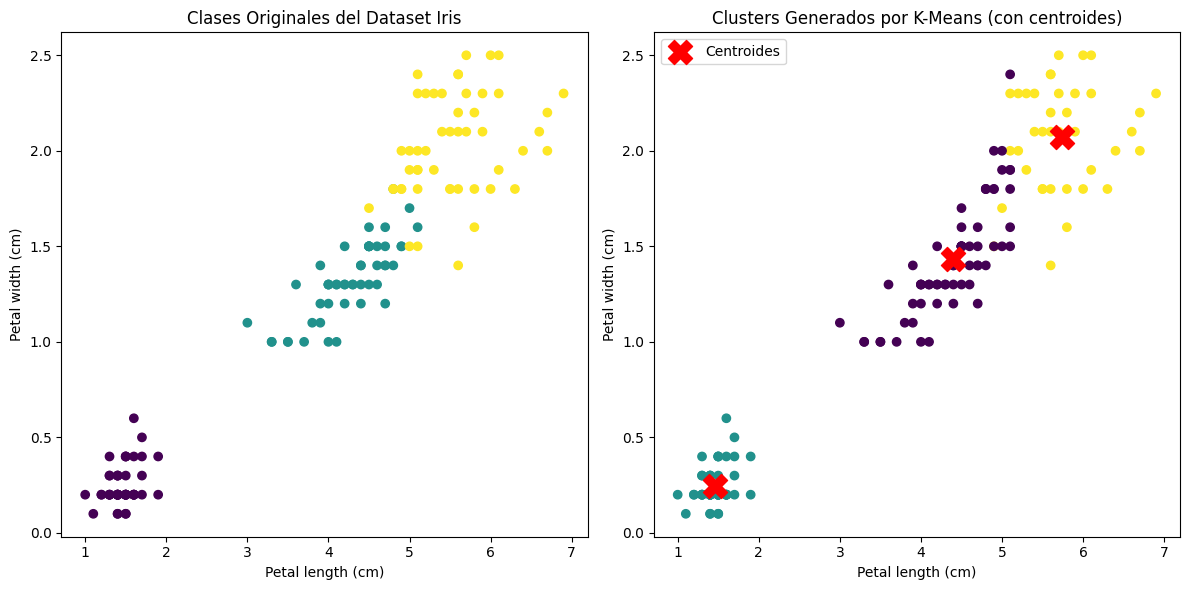

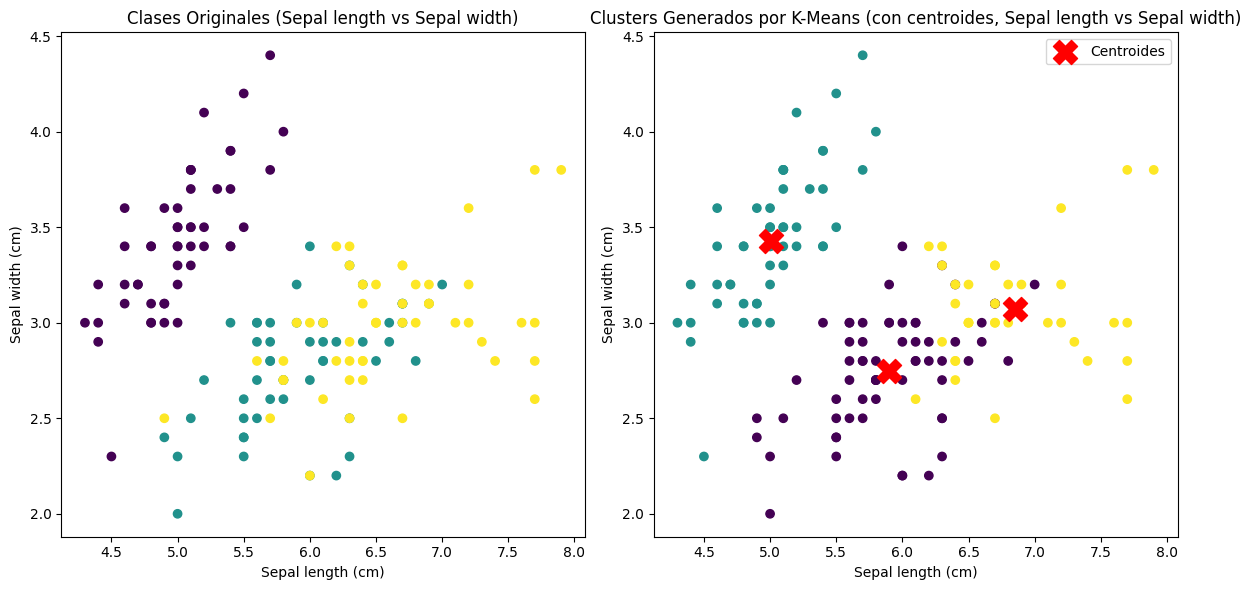

In [ ]:
# Obtener los centroides de K-Means
centroids = kmeans.cluster_centers_

# Graficar los clusters con los centroides usando las características Petal length y Petal width
plt.figure(figsize=(12, 6))

# Clases originales del dataset
plt.subplot(1, 2, 1)
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=y, cmap='viridis')
plt.title('Clases Originales del Dataset Iris')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')

# Clusters generados por K-Means con centroides
plt.subplot(1, 2, 2)
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=kmeans.labels_, cmap='viridis')
plt.scatter(centroids[:, 2], centroids[:, 3], s=300, c='red', marker='X', label='Centroides')
plt.title('Clusters Generados por K-Means (con centroides)')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()

plt.tight_layout()
plt.show()

# Graficar con Sepal length y Sepal width
plt.figure(figsize=(12, 6))

# Clases originales del dataset con Sepal length y Sepal width
plt.subplot(1, 2, 1)
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y, cmap='viridis')
plt.title('Clases Originales (Sepal length vs Sepal width)')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')

# Clusters generados por K-Means con Sepal length y Sepal width
plt.subplot(1, 2, 2)
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=kmeans.labels_, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroides')
plt.title('Clusters Generados por K-Means (con centroides, Sepal length vs Sepal width)')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.legend()

plt.tight_layout()
plt.show()


# Etapa 3: Número indicado de Clusters

Para evaluar la cantidad óptima de clusters en el dataset Iris, podemos utilizar dos métodos populares:

1. **Método del Codo:** Se basa en la suma de las distancias cuadradas de cada punto a su centroide más cercano. A medida que aumentamos el número de clusters, el error de distancias disminuye, pero en algún punto esa mejora se vuelve marginal. El punto donde se forma un "codo" en el gráfico es la cantidad óptima de clusters.

2. **Índice de Silueta:** Mide qué tan bien se ajusta cada punto a su propio cluster en comparación con otros clusters. Un valor cercano a 1 indica que los puntos están bien agrupados, mientras que un valor cercano a -1 indica que están mal agrupados.

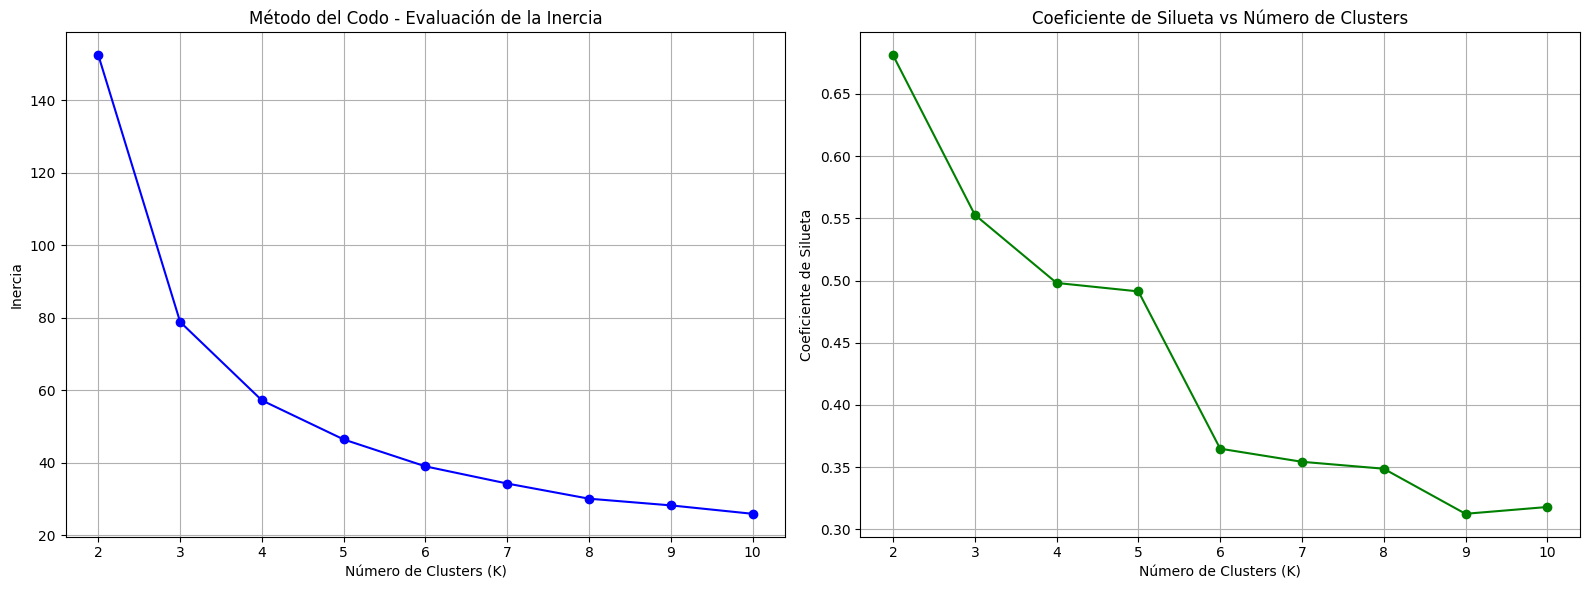

In [ ]:
from sklearn.metrics import silhouette_score

# Definir el rango de K
K_range = range(2, 11)

# Evaluar la inercia (método del codo) y el coeficiente de silueta para diferentes valores de K
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)

    # Guardar la inercia (método del codo)
    inertias.append(kmeans.inertia_)

    # Guardar el coeficiente de silueta
    if k > 1:
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Crear una figura con subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Método del Codo
ax[0].plot(K_range, inertias, 'bo-', label='Inercia')
ax[0].set_title('Método del Codo - Evaluación de la Inercia')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inercia')
ax[0].grid(True)

# Subplot 2: Coeficiente de Silueta
ax[1].plot(K_range, silhouette_scores, 'go-', label='Coeficiente de Silueta')
ax[1].set_title('Coeficiente de Silueta vs Número de Clusters')
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Coeficiente de Silueta')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Si nos guiamos por el método del codo indica que la mejor cantidad es 3 ya que ahí genera el quiebre, pero al evaluar el índice de la Silueta observamos que el valor máximo está en 2.

Por eso es bueno siempre validar ambos métodos.

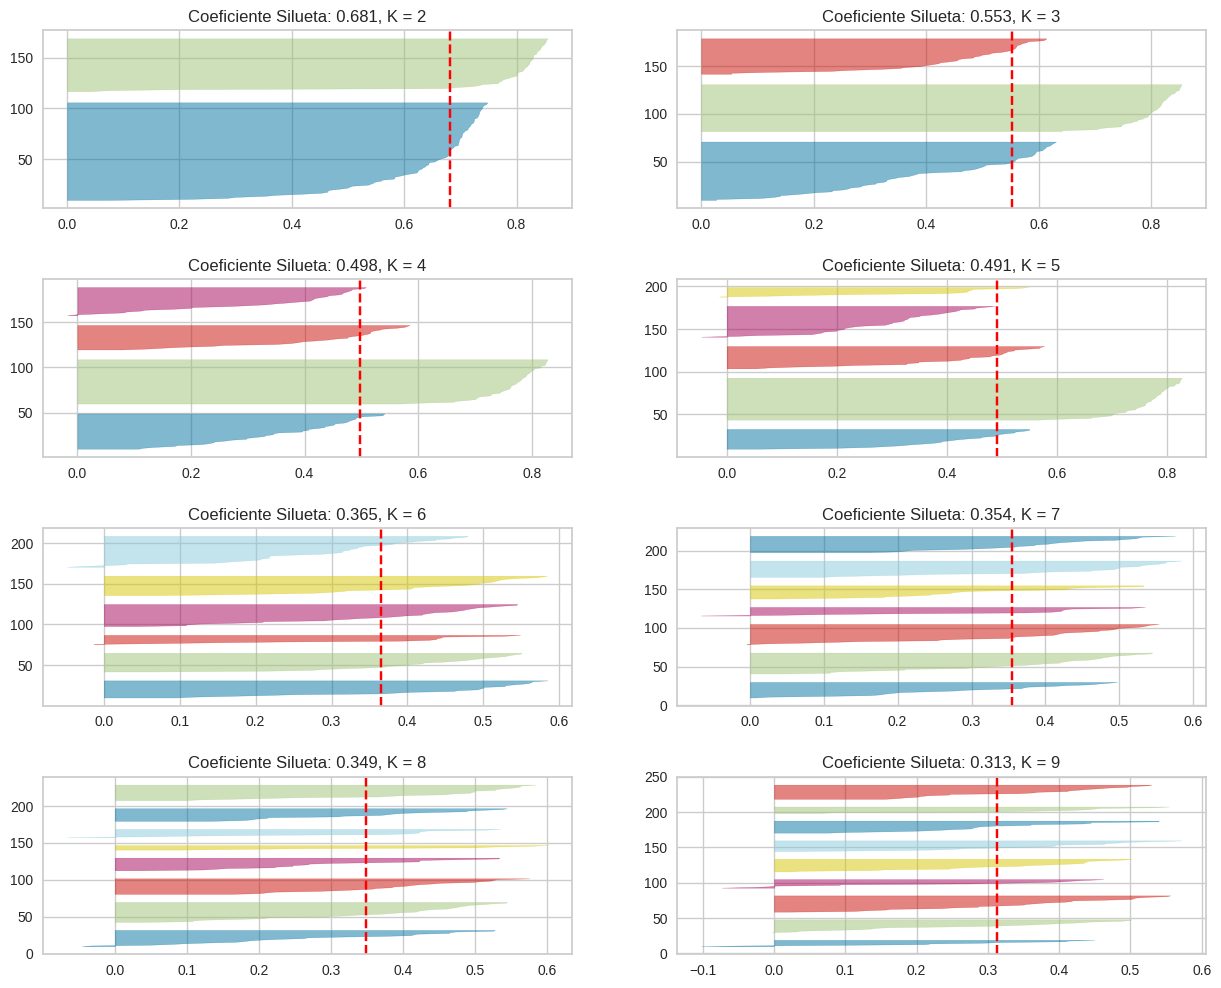

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
# Definimos la figura para múltiples subplots
fig, ax = plt.subplots(4, 2, figsize=(15, 12))  # Ajuste a 4 filas y 2 columnas para 8 gráficos
plt.subplots_adjust(hspace=0.4)  # Ajuste de espacio vertical entre subplots

# Iteramos sobre diferentes valores de K (número de clusters)
for i, k in enumerate(range(2, 10)):
    # Crear la instancia de KMeans para diferentes números de clusters
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)

    # Calcular el coeficiente de silueta
    score = silhouette_score(X, km.labels_, metric='euclidean')

    # Definir posición en el grid
    q, mod = divmod(i, 2)

    # Crear visualización de silueta con Yellowbrick
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q][mod])
    visualizer.set_title(f"Coeficiente Silueta: {score:.3f}, K = {k}")

    # Ajustar la visualización con los datos
    visualizer.fit(X)

plt.show()

# Etapa 4: Selección de Características mediante Correlación
En esta etapa, vamos a:

1. Analizar la correlación entre las características del dataset Iris.
2. Eliminar características altamente correlacionadas, ya que podrían aportar información redundante, y mantendremos aquellas que aporten más valor al modelo.
3. Aplicar nuevamente el modelo de K-Means con las características seleccionadas y comparar los resultados con el modelo original.

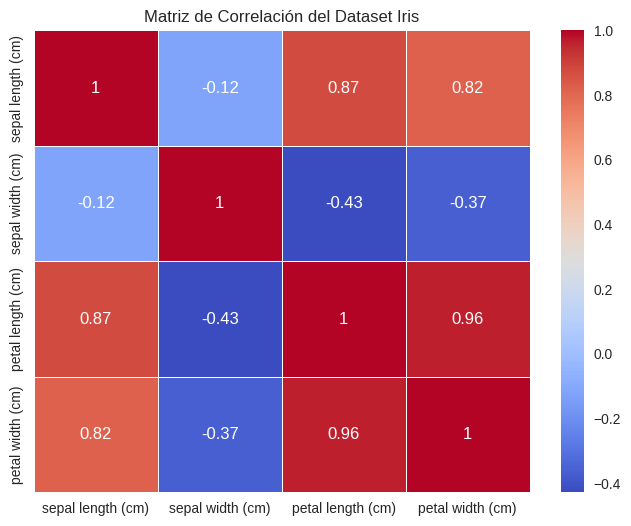

sepal length (cm)  petal length (cm)    0.871754
                   petal width (cm)     0.817941
petal length (cm)  sepal length (cm)    0.871754
                   petal width (cm)     0.962865
petal width (cm)   sepal length (cm)    0.817941
                   petal length (cm)    0.962865
dtype: float64

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = X.corr()

# Visualizar la matriz de correlación para identificar características altamente correlacionadas
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación del Dataset Iris')
plt.show()

# Ver las correlaciones que están por encima de un umbral (por ejemplo, 0.75) para eliminar variables redundantes
correlation_threshold = 0.75
high_corr = correlation_matrix[abs(correlation_matrix) > correlation_threshold].stack()
high_corr = high_corr[high_corr.index.get_level_values(0) != high_corr.index.get_level_values(1)]
high_corr

De acuerdo con la matriz de correlación:

* **Sepal length** está altamente correlacionada con **Petal length** (0.87) y **Petal width** (0.81).
* **Petal length** está altamente correlacionada con **Petal width** (0.96).

Aplicamos el modelo de K-Means con las características seleccionadas:
* Sepal length (mantener o eliminar según decisión).
* Sepal width (mantener).
* Petal length (mantener).

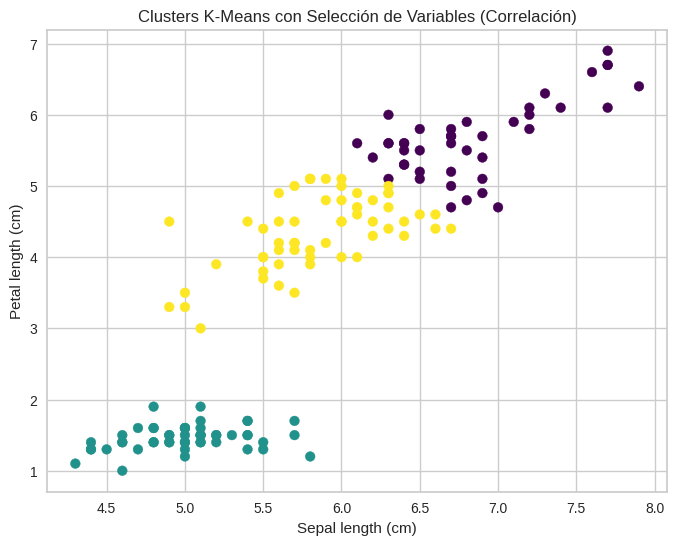

In [ ]:
# Eliminar las características altamente correlacionadas (eliminamos 'Petal width' y mantenemos 'Petal length')
X_selected = X.drop(columns=['petal width (cm)'])

# Aplicar K-Means al dataset reducido (con las características seleccionadas)
kmeans_corr = KMeans(n_clusters=3, random_state=42)
kmeans_corr.fit(X_selected)

# Graficar los clusters con las características seleccionadas (Sepal length, Sepal width y Petal length)
plt.figure(figsize=(8, 6))
plt.scatter(X_selected['sepal length (cm)'], X_selected['petal length (cm)'], c=kmeans_corr.labels_, cmap='viridis')
plt.title('Clusters K-Means con Selección de Variables (Correlación)')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.show()

# Etapa 5: Selección de Características mediante la Prueba de Chi-Cuadrado
En esta etapa, vamos a:

1. Aplicar la prueba de Chi-Cuadrado para seleccionar las características más relevantes. Este método es adecuado cuando las características y la variable objetivo son categóricas o discretas, pero puede ser adaptado a datos continuos utilizando discretización.
2. Seleccionar las características más relevantes en función de la prueba.
3. Aplicar nuevamente el modelo de K-Means con las características seleccionadas.

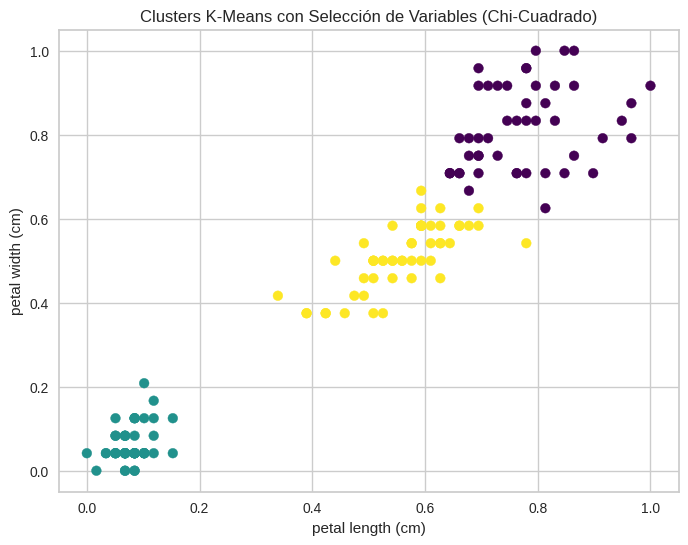

Index(['petal length (cm)', 'petal width (cm)'], dtype='object')

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Escalar los datos al rango [0, 1] ya que la prueba Chi-Cuadrado requiere valores no negativos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar la prueba de Chi-Cuadrado para seleccionar las 2 mejores características
chi2_selector = SelectKBest(chi2, k=2)
X_kbest = chi2_selector.fit_transform(X_scaled, y)

# Ver cuáles fueron las características seleccionadas
selected_features = X.columns[chi2_selector.get_support()]

# Aplicar K-Means a las características seleccionadas
kmeans_chi2 = KMeans(n_clusters=3, random_state=42)
kmeans_chi2.fit(X_kbest)

# Graficar los clusters con las características seleccionadas
plt.figure(figsize=(8, 6))
plt.scatter(X_kbest[:, 0], X_kbest[:, 1], c=kmeans_chi2.labels_, cmap='viridis')
plt.title('Clusters K-Means con Selección de Variables (Chi-Cuadrado)')
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()

# Mostrar las características seleccionadas
selected_features


La prueba de Chi-Cuadrado ha seleccionado las siguientes dos características como las más relevantes:

* Petal length (cm)
* Petal width (cm)

# Etapa 6: Selección de Características mediante Random Forest

Dado que Random Forest normalmente requiere una variable objetivo para entrenar un modelo, en un escenario completamente no supervisado, la selección de características basada en un modelo supervisado no sería aplicable directamente. Sin embargo, podríamos aproximar la importancia de las características con técnicas como clustering basado en Random Forest.

Como alternativa en este contexto no supervisado, podemos:

* Aplicar Random Forest de manera supervisada utilizando una variable pseudo-objetivo para evaluar la importancia de las características.
* Generar clusters con K-Means y utilizar esos clusters como una pseudo-clase para entrenar el Random Forest y obtener la importancia de las características.


Vamos a proceder con esta aproximación, generando clusters con K-Means y utilizando esos clusters como la variable y para entrenar Random Forest y seleccionar las características más importantes.

Procedimiento:
1. Generar clusters con K-Means como pseudo-objetivo.
2. Entrenar Random Forest utilizando los clusters como y.
3. Evaluar la importancia de las características con Random Forest y aplicar K-Means sobre las características seleccionadas.

,Feature,Importance
2,petal length (cm),0.496584
3,petal width (cm),0.302880
0,sepal length (cm),0.178471
1,sepal width (cm),0.022064


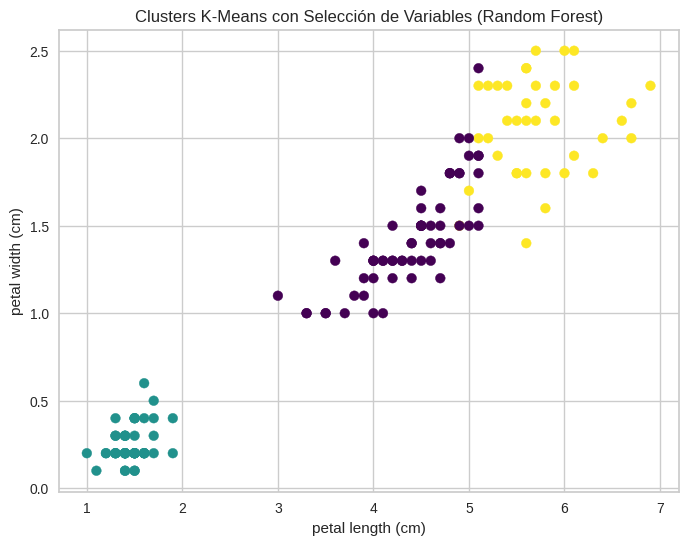

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Generar clusters con K-Means para usarlos como pseudo-clases
kmeans_pseudo = KMeans(n_clusters=3, random_state=42)
clusters_pseudo = kmeans_pseudo.fit_predict(X)

# Entrenar Random Forest utilizando los clusters como pseudo-objetivo
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X, clusters_pseudo)

# Obtener la importancia de las características desde el modelo Random Forest
feature_importances_rf = random_forest.feature_importances_

# Crear un DataFrame para visualizar las importancias de características
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances_rf
}).sort_values(by='Importance', ascending=False)

# Seleccionar las características más importantes
selected_rf_features = rf_importance_df[rf_importance_df['Importance'] > 0]['Feature']

# Aplicar K-Means nuevamente a las características seleccionadas
X_rf_selected = X[selected_rf_features]
kmeans_rf = KMeans(n_clusters=3, random_state=42)
kmeans_rf.fit(X_rf_selected)

# Mostrar las características seleccionadas por Random Forest
display(rf_importance_df)

# Graficar los clusters usando las características seleccionadas por Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(X_rf_selected.iloc[:, 0], X_rf_selected.iloc[:, 1], c=kmeans_rf.labels_, cmap='viridis')
plt.title('Clusters K-Means con Selección de Variables (Random Forest)')
plt.xlabel(selected_rf_features.iloc[0])
plt.ylabel(selected_rf_features.iloc[1])
plt.show()




El Random Forest, utilizando los clusters generados por K-Means como pseudo-clases, ha identificado las siguientes características como las más importantes:

* Petal length (cm) (0.50)
* Petal width (cm) (0.30)
* Sepal length (cm) (0.18)
* Sepal width (cm) (0.02)

Luego, aplicamos K-Means sobre las características seleccionadas, y el gráfico muestra los clusters generados usando las características más relevantes según Random Forest.

Ahora que hemos seleccionado dos características clave (Petal length y Petal width) utilizando Random Forest, podemos evaluar si el número de clusters óptimo es realmente 3.


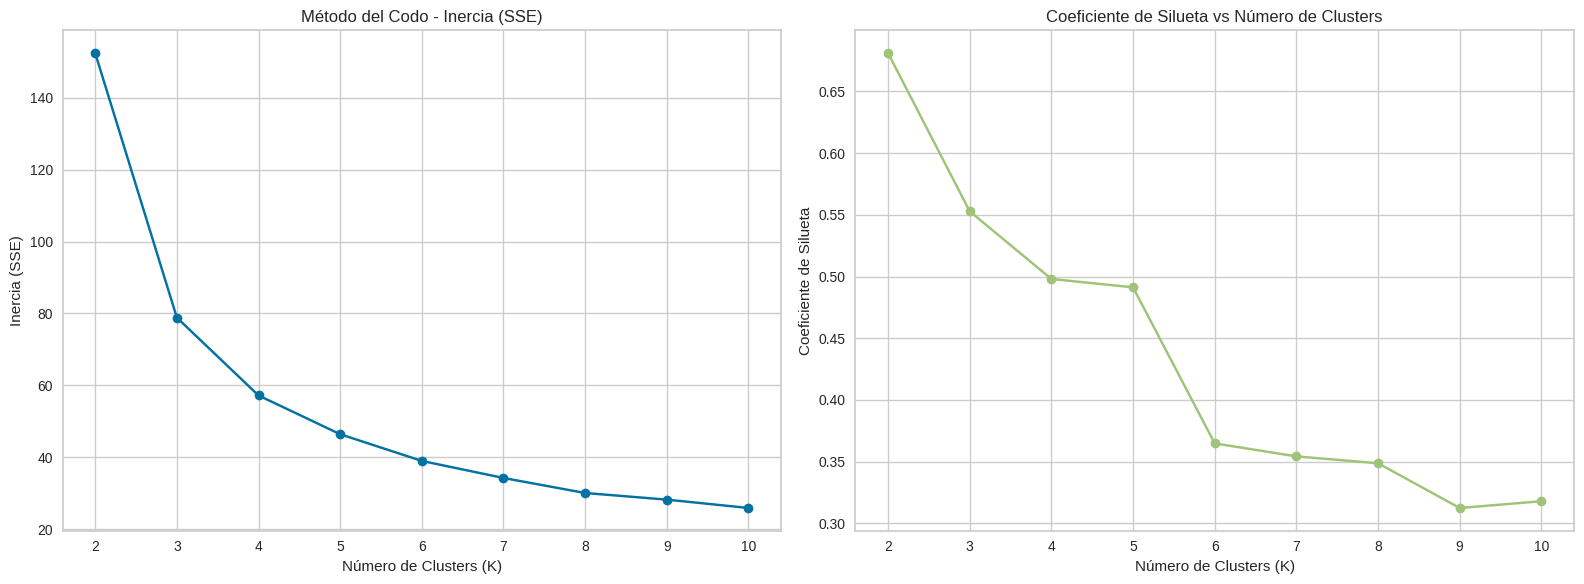

In [ ]:
# Método del Codo y Coeficiente de Silueta para las características seleccionadas (Petal length y Petal width)
inertias_rf = []
silhouette_scores_rf = []
K_range = range(2, 11)

# Evaluar el número de clusters de 2 a 10
for k in K_range:
    kmeans_rf = KMeans(n_clusters=k, random_state=42)
    kmeans_rf.fit(X_rf_selected)

    # Calcular la inercia (Suma de los Errores Cuadrados - SSE)
    inertias_rf.append(kmeans_rf.inertia_)

    # Calcular el coeficiente de silueta
    if k > 1:
        silhouette_avg_rf = silhouette_score(X_rf_selected, kmeans_rf.labels_)
        silhouette_scores_rf.append(silhouette_avg_rf)

# Visualización del método del Codo y del coeficiente de Silueta
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Método del Codo
ax[0].plot(K_range, inertias_rf, 'bo-', label='Inercia')
ax[0].set_title('Método del Codo - Inercia (SSE)')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inercia (SSE)')
ax[0].grid(True)

# Subplot 2: Coeficiente de Silueta
ax[1].plot(K_range, silhouette_scores_rf, 'go-', label='Coeficiente de Silueta')
ax[1].set_title('Coeficiente de Silueta vs Número de Clusters')
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Coeficiente de Silueta')
ax[1].grid(True)

plt.tight_layout()
plt.show()


Nuevamente observamos que el número óptimo sigue siendo 2

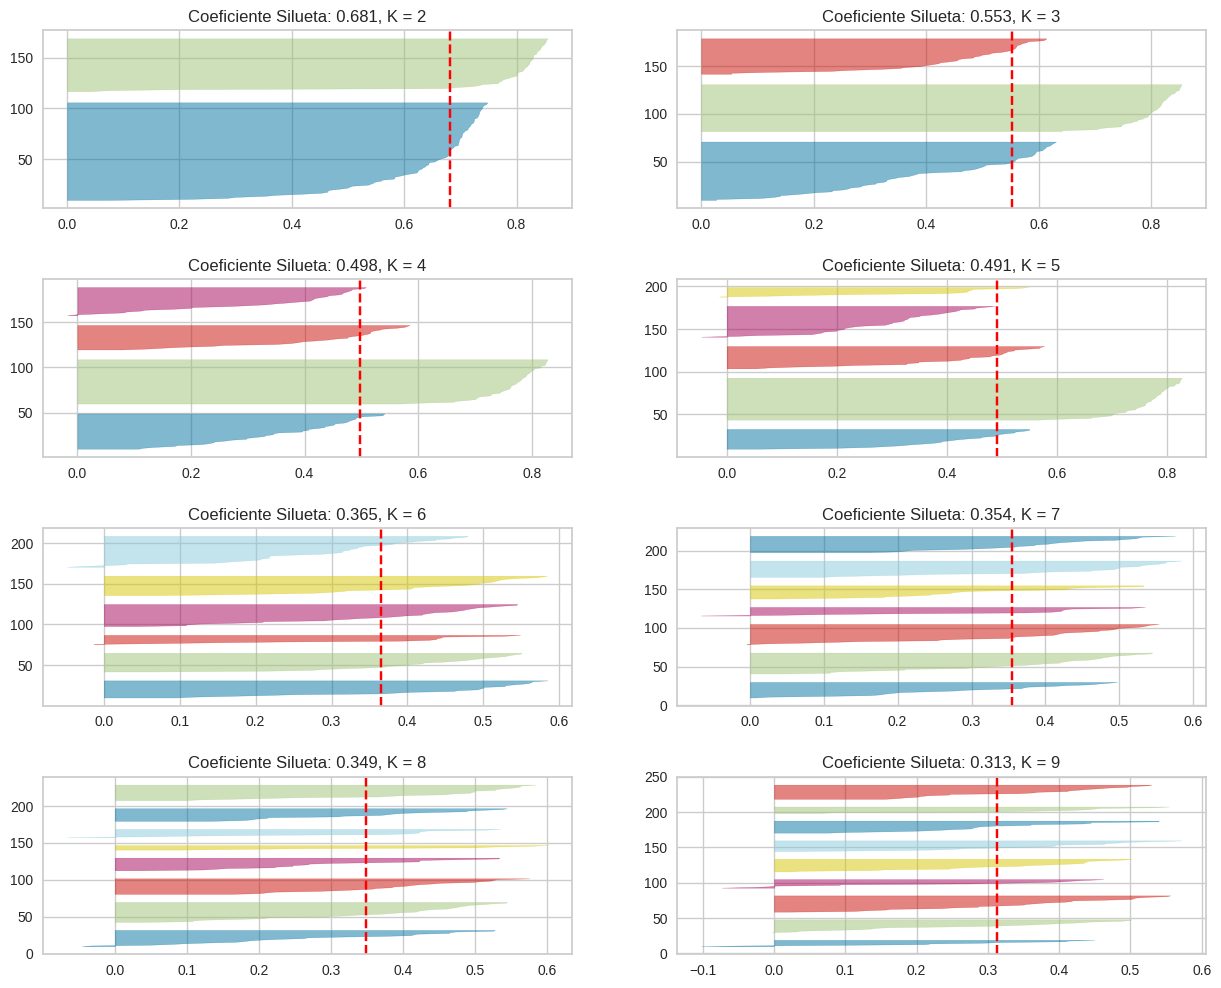

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
# Definimos la figura para múltiples subplots
fig, ax = plt.subplots(4, 2, figsize=(15, 12))  # Ajuste a 4 filas y 2 columnas para 8 gráficos
plt.subplots_adjust(hspace=0.4)  # Ajuste de espacio vertical entre subplots

# Iteramos sobre diferentes valores de K (número de clusters)
for i, k in enumerate(range(2, 10)):
    # Crear la instancia de KMeans para diferentes números de clusters
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_rf_selected)

    # Calcular el coeficiente de silueta
    score = silhouette_score(X_rf_selected, km.labels_, metric='euclidean')

    # Definir posición en el grid
    q, mod = divmod(i, 2)

    # Crear visualización de silueta con Yellowbrick
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q][mod])
    visualizer.set_title(f"Coeficiente Silueta: {score:.3f}, K = {k}")

    # Ajustar la visualización con los datos
    visualizer.fit(X_rf_selected)

plt.show()